In [24]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [25]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [26]:
CLIENT_FOLDER = "../data/clients_iid"
# CLIENT_FOLDER = "../data/clients_noniid"

NUM_CLIENTS = 10
LOCAL_EPOCHS = 3
ROUNDS = 70
BATCH_SIZE = 256
LR = 0.0007

In [27]:
X_train_full = pd.read_csv("../data/X_train_enc.csv")
X_test = pd.read_csv("../data/X_test_enc.csv")
y_test = pd.read_csv("../data/y_test.csv")["label"].values

print("Full train shape:", X_train_full.shape)
print("Test shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Full train shape: (175341, 196)
Test shape: (82332, 196)
Test labels shape: (82332,)


In [28]:
scaler = StandardScaler()
scaler.fit(X_train_full)

X_test_scaled = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

print("Scaled test tensor shape:", X_test_tensor.shape)

Scaled test tensor shape: torch.Size([82332, 196])


In [29]:
class IDSNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [30]:
def load_client_data(client_id, client_folder, scaler, batch_size):
    X_client = pd.read_csv(f"{client_folder}/client_{client_id}_X.csv")
    y_client = pd.read_csv(f"{client_folder}/client_{client_id}_y.csv")["label"].values

    X_client_scaled = scaler.transform(X_client)

    X_tensor = torch.tensor(X_client_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_client.reshape(-1, 1), dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    return loader, len(X_client)

In [31]:
def train_local_model(global_model, client_loader, local_epochs, lr):
    local_model = copy.deepcopy(global_model)
    local_model.train()

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)

    for epoch in range(local_epochs):
        for xb, yb in client_loader:
            optimizer.zero_grad()

            logits = local_model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

    return local_model.state_dict()

In [32]:
def fedavg(client_state_dicts, client_sizes):
    total_size = sum(client_sizes)

    avg_state = copy.deepcopy(client_state_dicts[0])

    for key in avg_state.keys():
        avg_state[key] = client_state_dicts[0][key] * (client_sizes[0] / total_size)

    for i in range(1, len(client_state_dicts)):
        for key in avg_state.keys():
            avg_state[key] += client_state_dicts[i][key] * (client_sizes[i] / total_size)

    return avg_state

In [33]:
def evaluate_global_model(model, X_test_tensor, y_test):
    model.eval()

    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs >= 0.5).astype(int)

    results = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probs)
    }

    return results, preds, probs

In [34]:
input_dim = X_train_full.shape[1]
global_model = IDSNet(input_dim)

print("Global model initialized with input dimension:", input_dim)

Global model initialized with input dimension: 196


In [35]:
history = []

for rnd in range(ROUNDS):
    print(f"\n--- Federated Round {rnd+1}/{ROUNDS} ---")

    client_state_dicts = []
    client_sizes = []

    for client_id in range(NUM_CLIENTS):
        client_loader, client_size = load_client_data(
            client_id=client_id,
            client_folder=CLIENT_FOLDER,
            scaler=scaler,
            batch_size=BATCH_SIZE
        )

        local_state = train_local_model(
            global_model=global_model,
            client_loader=client_loader,
            local_epochs=LOCAL_EPOCHS,
            lr=LR
        )

        client_state_dicts.append(local_state)
        client_sizes.append(client_size)

        print(f"Client {client_id} trained on {client_size} samples")

    new_global_state = fedavg(client_state_dicts, client_sizes)
    global_model.load_state_dict(new_global_state)

    round_results, _, _ = evaluate_global_model(global_model, X_test_tensor, y_test)
    round_results["round"] = rnd + 1
    history.append(round_results)

    print("Round results:", round_results)


--- Federated Round 1/70 ---
Client 0 trained on 17535 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 17534 samples
Client 8 trained on 17534 samples
Client 9 trained on 17534 samples
Round results: {'accuracy': 0.8201549822669193, 'precision': 0.7584805324571952, 'recall': 0.9879555281037677, 'f1': 0.8581419634217611, 'roc_auc': np.float64(0.9630399345012532), 'round': 1}

--- Federated Round 2/70 ---
Client 0 trained on 17535 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 17534 samples
Client 8 trained on 17534 samples
Client 9 trained on 17534 samples
Round results: {'accuracy': 0.8250376524316183, 'precision': 0.76366

In [36]:
history_df = pd.DataFrame(history)
print(history_df)

    accuracy  precision    recall        f1   roc_auc  round
0   0.820155   0.758481  0.987956  0.858142  0.963040      1
1   0.825038   0.763662  0.988000  0.861465  0.966135      2
2   0.828730   0.768377  0.986235  0.863781  0.967748      3
3   0.834026   0.775696  0.982727  0.867024  0.968957      4
4   0.837147   0.780143  0.980566  0.868947  0.969864      5
..       ...        ...       ...       ...       ...    ...
65  0.871508   0.824606  0.973749  0.892993  0.978763     66
66  0.873597   0.827191  0.973882  0.894562  0.978840     67
67  0.870075   0.819434  0.979970  0.892541  0.979433     68
68  0.871532   0.823561  0.975713  0.893204  0.978983     69
69  0.874800   0.828654  0.974014  0.895473  0.979090     70

[70 rows x 6 columns]


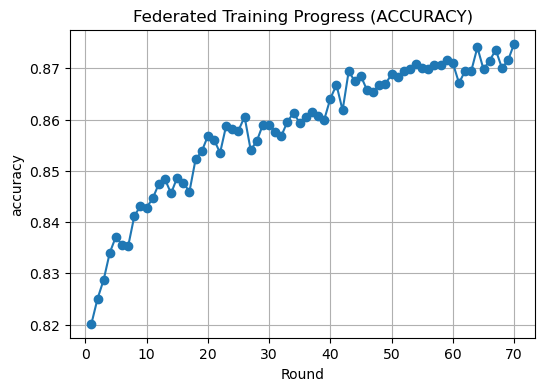

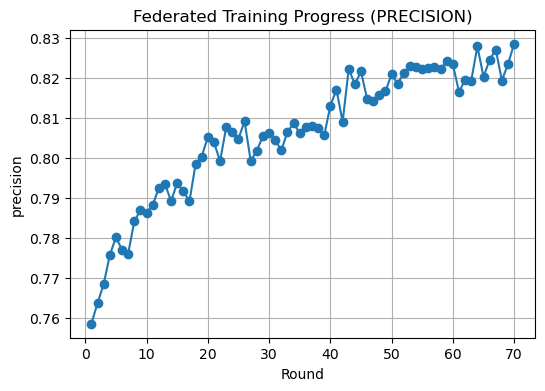

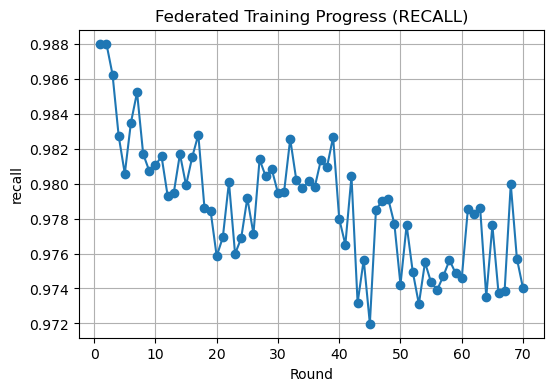

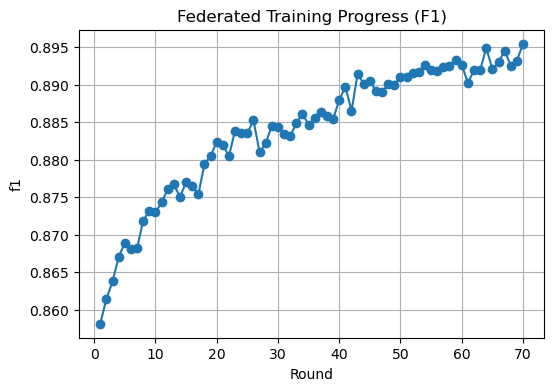

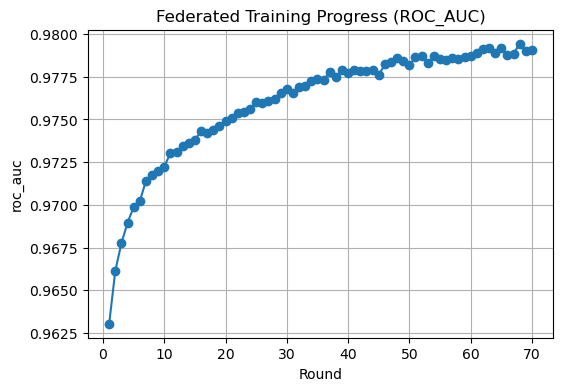

In [37]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(history_df["round"], history_df[metric], marker="o")
    plt.title(f"Federated Training Progress ({metric.upper()})")
    plt.xlabel("Round")
    plt.ylabel(metric)
    plt.grid(True)
    plt.show()

Final Federated Results:
{'accuracy': 0.874799591896225, 'precision': 0.828654004954583, 'recall': 0.9740139415865172, 'f1': 0.8954733511803359, 'roc_auc': np.float64(0.9790900339477392)}


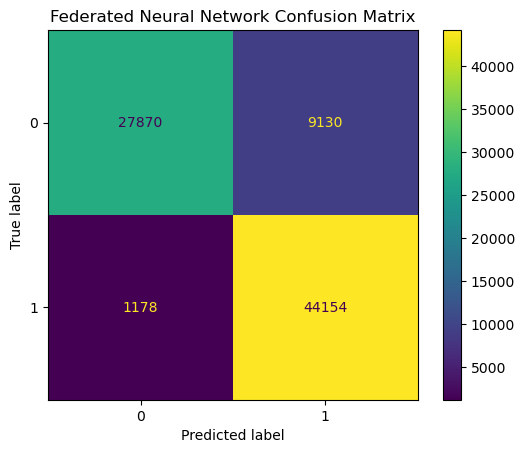

In [38]:
final_results, final_pred, final_prob = evaluate_global_model(global_model, X_test_tensor, y_test)
import pandas as pd

pd.DataFrame({
    "y_true": y_test,
    "y_prob": final_prob
}).to_csv("../results/fl_iid_predictions.csv", index=False)

print("Final Federated Results:")
print(final_results)

cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Federated Neural Network Confusion Matrix")
plt.show()

In [39]:
os.makedirs("../results", exist_ok=True)

history_df.to_csv("../results/fl_iid_rounds.csv", index=False)

final_df = pd.DataFrame([{
    "model": "FederatedNN_IID",
    **final_results
}])

final_df.to_csv("../results/fl_iid_final.csv", index=False)

print("Saved:")
print(" - ../results/fl_iid_rounds.csv")
print(" - ../results/fl_iid_final.csv")

Saved:
 - ../results/fl_iid_rounds.csv
 - ../results/fl_iid_final.csv


Non-IID

In [40]:
CLIENT_FOLDER = "../data/clients_noniid"

NUM_CLIENTS = 10
LOCAL_EPOCHS = 3
ROUNDS = 70
BATCH_SIZE = 256
LR = 0.0007

In [41]:
input_dim = X_train_full.shape[1]
global_model = IDSNet(input_dim)

print("Fresh global model initialized for non-IID training.")

Fresh global model initialized for non-IID training.


In [42]:
history = []

for rnd in range(ROUNDS):
    print(f"\n--- Non-IID Federated Round {rnd+1}/{ROUNDS} ---")

    client_state_dicts = []
    client_sizes = []

    for client_id in range(NUM_CLIENTS):
        client_loader, client_size = load_client_data(
            client_id=client_id,
            client_folder=CLIENT_FOLDER,
            scaler=scaler,
            batch_size=BATCH_SIZE
        )

        local_state = train_local_model(
            global_model=global_model,
            client_loader=client_loader,
            local_epochs=LOCAL_EPOCHS,
            lr=LR
        )

        client_state_dicts.append(local_state)
        client_sizes.append(client_size)

        print(f"Client {client_id} trained on {client_size} samples")

    new_global_state = fedavg(client_state_dicts, client_sizes)
    global_model.load_state_dict(new_global_state)

    round_results, _, _ = evaluate_global_model(global_model, X_test_tensor, y_test)
    round_results["round"] = rnd + 1
    history.append(round_results)

    print("Round results:", round_results)


--- Non-IID Federated Round 1/70 ---
Client 0 trained on 17534 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 13922 samples
Client 8 trained on 14028 samples
Client 9 trained on 14904 samples
Round results: {'accuracy': 0.7727250643735121, 'precision': 0.7090926228478069, 'recall': 0.9957204623665402, 'f1': 0.8283113737292179, 'roc_auc': np.float64(0.8983674926249817), 'round': 1}

--- Non-IID Federated Round 2/70 ---
Client 0 trained on 17534 samples
Client 1 trained on 17534 samples
Client 2 trained on 17534 samples
Client 3 trained on 17534 samples
Client 4 trained on 17534 samples
Client 5 trained on 17534 samples
Client 6 trained on 17534 samples
Client 7 trained on 13922 samples
Client 8 trained on 14028 samples
Client 9 trained on 14904 samples
Round results: {'accuracy': 0.7812272263518437, 'pre

In [43]:
history_df = pd.DataFrame(history)
print(history_df)

    accuracy  precision    recall        f1   roc_auc  round
0   0.772725   0.709093  0.995720  0.828311  0.898367      1
1   0.781227   0.717551  0.993890  0.833410  0.929095      2
2   0.788102   0.724042  0.994000  0.837811  0.940853      3
3   0.789559   0.725172  0.994816  0.838858  0.950169      4
4   0.791904   0.727672  0.994088  0.840268  0.953858      5
..       ...        ...       ...       ...       ...    ...
65  0.803807   0.737564  0.999206  0.848677  0.973450     66
66  0.803758   0.737477  0.999316  0.848659  0.974082     67
67  0.804098   0.737837  0.999250  0.848873  0.973891     68
68  0.802045   0.735811  0.999250  0.847531  0.973900     69
69  0.799215   0.732984  0.999404  0.845708  0.974746     70

[70 rows x 6 columns]


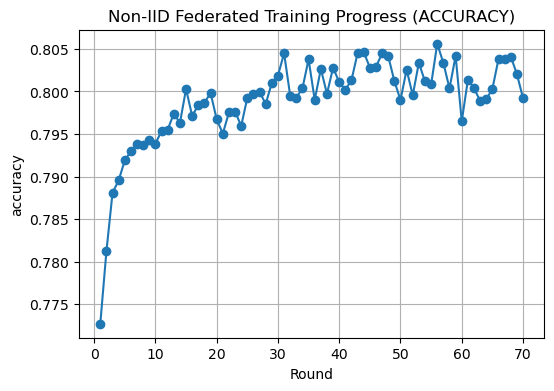

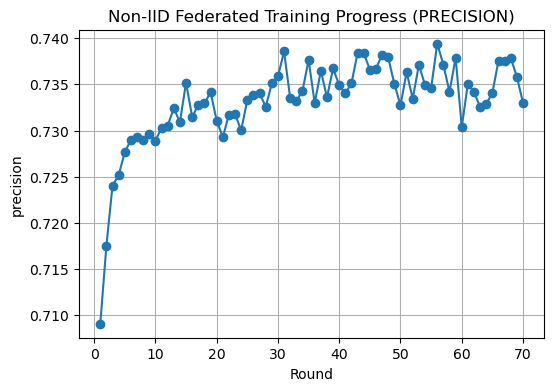

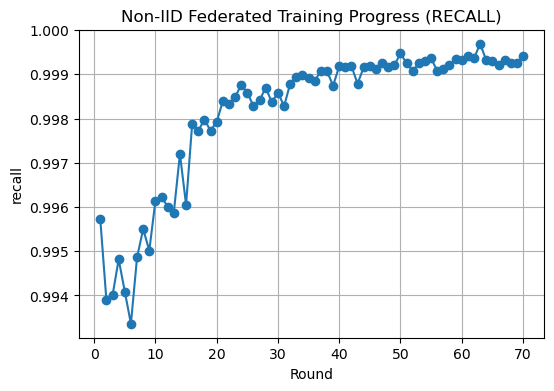

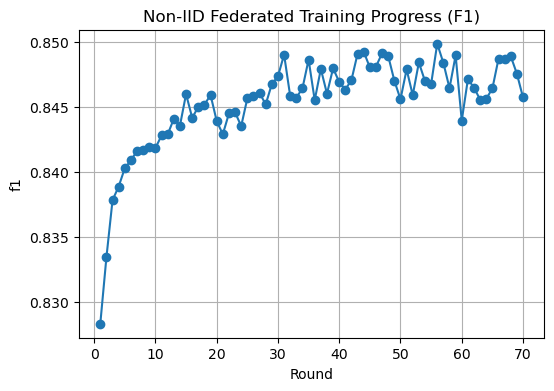

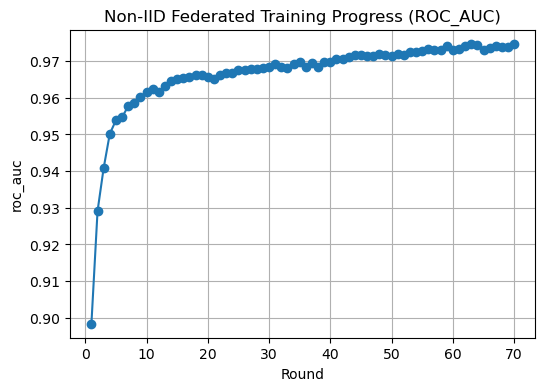

In [44]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(history_df["round"], history_df[metric], marker="o")
    plt.title(f"Non-IID Federated Training Progress ({metric.upper()})")
    plt.xlabel("Round")
    plt.ylabel(metric)
    plt.grid(True)
    plt.show()

In [45]:
final_results, final_pred, final_prob = evaluate_global_model(global_model, X_test_tensor, y_test)
pd.DataFrame({
    "y_true": y_test,
    "y_prob": final_prob
}).to_csv("../results/fl_noniid_predictions.csv", index=False)

print("Final Non-IID Federated Results:")
print(final_results)

Final Non-IID Federated Results:
{'accuracy': 0.7992153719088568, 'precision': 0.7329838696629941, 'recall': 0.9994043942468896, 'f1': 0.845707992271866, 'roc_auc': np.float64(0.9747455445827897)}


In [46]:
os.makedirs("../results", exist_ok=True)

history_df.to_csv("../results/fl_noniid_rounds.csv", index=False)

final_df = pd.DataFrame([{
    "model": "FederatedNN_nonIID",
    **final_results
}])

final_df.to_csv("../results/fl_noniid_final.csv", index=False)

print("Saved:")
print(" - ../results/fl_noniid_rounds.csv")
print(" - ../results/fl_noniid_final.csv")

Saved:
 - ../results/fl_noniid_rounds.csv
 - ../results/fl_noniid_final.csv
